<b>¡Hola Diana!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!

# OilyGiant — Selección de la mejor región (Sprint 11)
**Autora:** Diana Reyes  
**Objetivo:** Predecir `product` (miles de barriles) por región con regresión lineal y evaluar beneficios y riesgos (bootstrapping) para elegir la región óptima.


## Introducción y contexto
- Empresa: **OilyGiant**
- Tarea: Construir modelo (regresión lineal) para predecir volumen de reservas (`product`, miles de barriles) en 3 regiones.
- Restricciones:
  - Solo **regresión lineal**.
  - 500 puntos explorados por región; se desarrollan **200 pozos**.
  - Presupuesto: **$100M** para 200 pozos.
  - Ingreso por unidad de `product`: **$4,500** (porque 1k barriles * $4.5/barril).
  - **Riesgo de pérdida < 2.5%**; entre las que cumplan, elegir **mayor beneficio promedio**.


### Importación de librerías

In [1]:
import os
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats as st

plt.rcParams["figure.figsize"] = (8,5)

# Detecta el directorio del proyecto
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

# Intento 1: carpeta "data" dentro del proyecto
DATA_DIR = PROJECT_DIR / "data"

# Si no existe, usamos /datasets
if not DATA_DIR.exists():
    DATA_DIR = Path("/datasets")

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)


PROJECT_DIR: /app
DATA_DIR: /datasets


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [14], el manejo de rutas con <code>pathlib</code> y la configuración de <code>PROJECT_DIR</code>/<code>DATA_DIR</code> es un acierto importante. Esto hace tu notebook reproducible desde distintos entornos y evita errores por rutas relativas. Además, ajustar <code>plt.rcParams["figure.figsize"]</code> al inicio centraliza el estilo de gráficos y mejora la consistencia. Muy bien pensado para facilitar la ejecución y la lectura.
</div>

## Carga y exploración de datos


In [2]:
# Cargar los datasets de las tres regiones
paths = {
    "region_0": DATA_DIR / "geo_data_0.csv",
    "region_1": DATA_DIR / "geo_data_1.csv",
    "region_2": DATA_DIR / "geo_data_2.csv",
}

# Leer cada dataset en un diccionario de DataFrames
dfs = {name: pd.read_csv(path) for name, path in paths.items()}

# Mostrar resumen de forma y columnas de cada región
for name, df in dfs.items():
    print(f"\n=== {name} ===")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    print(f"Columnas: {list(df.columns)}")




=== region_0 ===
Filas: 100000, Columnas: 5
Columnas: ['id', 'f0', 'f1', 'f2', 'product']

=== region_1 ===
Filas: 100000, Columnas: 5
Columnas: ['id', 'f0', 'f1', 'f2', 'product']

=== region_2 ===
Filas: 100000, Columnas: 5
Columnas: ['id', 'f0', 'f1', 'f2', 'product']


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [7], cargar los tres datasets en un diccionario <code>dfs</code> y recorrerlos para mostrar forma y columnas es una decisión clara y escalable. Esta estructura te permite aplicar el mismo flujo sin duplicar código, y deja evidencia temprana de que las tres regiones comparten esquema (mismas columnas), lo cual es clave para entrenar modelos homogéneos por región.
</div>

In [3]:
# Vista previa y estructura de los datos
for name, df in dfs.items():
    print(f"\n=== {name} ===")
    print("Vista Previa de las tres primeras filas:")
    display(df.head(3))
    print("Inspección de los datos:")
    display(df.info())
    print("Estadísticas descriptivas:")
    display(df.describe().T)
    print("Valores nulos por columna:")
    display(df.isna().sum())
    print("Valores duplicados encontrados:", df.duplicated().sum())


=== region_0 ===
Vista Previa de las tres primeras filas:


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647


Inspección de los datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


None

Estadísticas descriptivas:


...

Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
f0,100000.0,0.002023,1.732045,-8.760004,-1.162288,0.009424,1.158535,7.238262
f1,100000.0,-0.002081,1.730417,-7.084020,-1.174820,-0.009482,1.163678,7.844801
f2,100000.0,2.495128,3.473445,-11.970335,0.130359,2.484236,4.858794,16.739402
product,100000.0,95.000000,44.749921,0.000000,59.450441,94.925613,130.595027,190.029838


Valores nulos por columna:


id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

Valores duplicados encontrados: 0


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [11], el diagnóstico inicial (<code>head</code>, <code>info</code>, <code>describe</code>, nulos y duplicados) está completo y bien ordenado. Este EDA confirma tipos, escalas y calidad de datos en cada región. Esa verificación evita sorpresas en el modelado y da confianza para avanzar sin preprocesamientos innecesarios.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
A partir de la celda [11], tus conclusiones del EDA están bien justificadas con estadísticas (medias y desviaciones) y conectan con el impacto en el modelado (estabilidad vs. dispersión). Este puente entre datos y método ayuda a tomar decisiones fundamentadas en cada región y orienta expectativas sobre el error de predicción.
</div>

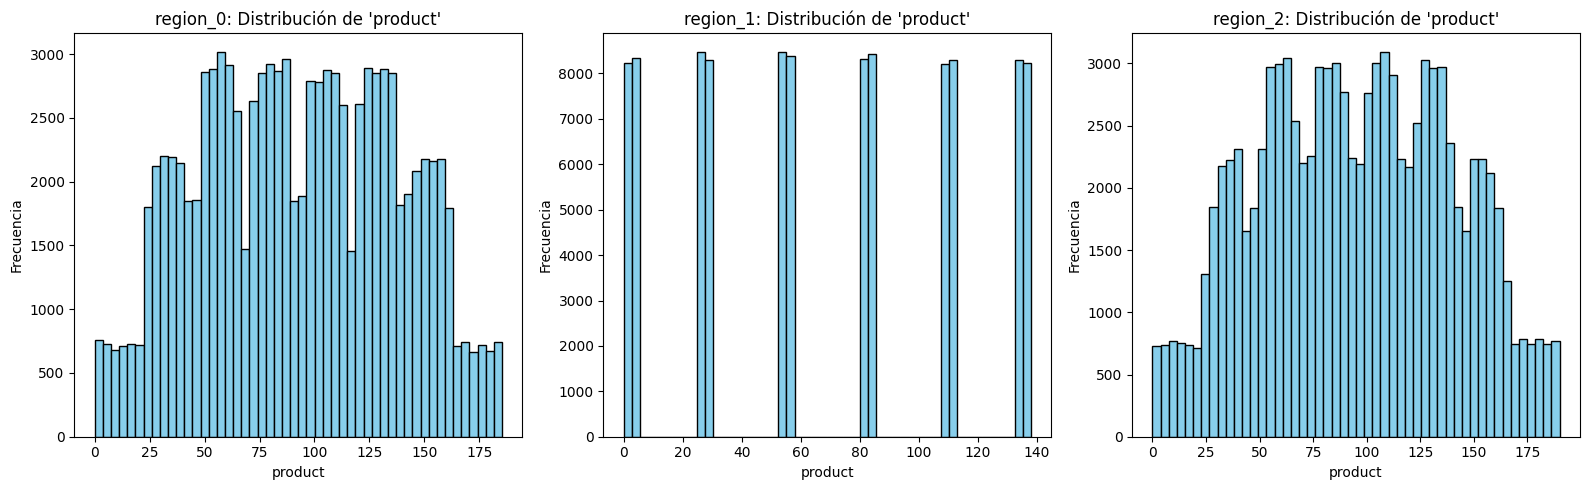

In [4]:
# Visualización inicial de las variables para ver si
# las variables numéricas tienen rangos similares entre regiones.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (name, df) in enumerate(dfs.items()):
    axes[i].hist(df["product"], bins=50, color="skyblue", edgecolor="black")
    axes[i].set_title(f"{name}: Distribución de 'product'")
    axes[i].set_xlabel("product")
    axes[i].set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()


### Observaciones del EDA inicial

- Cada dataset contiene **100,000 registros** y **5 columnas**: `id`, `f0`, `f1`, `f2` y `product`.  
- No se detectan valores nulos ni duplicados.  
- La variable objetivo `product` (volumen de reservas) muestra distribuciones muy distintas por región:

#### Región 0
- Distribución bastante uniforme, sin anomalías visibles.  
- Media de `product` ≈ 92.5, con desviación estándar ≈ 44.3.  
- Las variables `f0`, `f1` y `f2` tienen valores moderados y escalas consistentes.  
- Se perfila como una **región estable** y predecible.

#### Región 1
- Presenta un patrón muy irregular en la distribución de `product` (pocos picos aislados con huecos entre ellos).  
- Medias de `f0` y `f1` fuera de rango (≈ 1.14 y -4.79) y desviaciones estándar muy altas (≈ 8.96 y 5.12).  
- Sugiere **una muestra con valores anómalos o escalas alteradas**, posiblemente generada bajo condiciones diferentes.  
- Podría afectar el desempeño de los modelos de regresión.

#### Región 2
- Distribución similar a la Región 0, pero con ligera mayor dispersión.  
- Media de `product` ≈ 95.0 (la más alta de las tres).  
- `f2` presenta mayor variabilidad (std ≈ 3.47), lo que podría indicar **potencial predictivo alto pero mayor riesgo**.

**Conclusión preliminar:**  
> La **Región 2** parece tener el mayor potencial en reservas y rentabilidad esperada,  
> pero la **Región 0** muestra mayor estabilidad y consistencia.  
> La **Región 1** exhibe comportamientos atípicos que podrían limitar la fiabilidad de sus predicciones.


### Preparación de datos para el modelado

No se requirió una etapa adicional de preprocesamiento ya que:
- Todas las variables (`f0`, `f1`, `f2`, `product`) son numéricas.
- No existen valores ausentes ni duplicados.
- No hay variables categóricas que requieran codificación.
- Las escalas de las variables son comparables y adecuadas para el modelo de regresión lineal.

Por lo tanto, los datos se utilizaran directamente para la división en conjuntos de entrenamiento y validación (75/25).


## División de datos y modelado por región

En esta sección se realizará la división de los datos en conjuntos de entrenamiento y validación (75/25) para cada región.  
Luego se entrenará un modelo de **Regresión Lineal** (`LinearRegression`) para predecir el volumen de reservas (`product`).

El objetivo es comparar:
- El error cuadrático medio (RMSE) de cada modelo.  
- El valor promedio de las reservas predichas (`mean_pred`).  

Estos indicadores permitirán identificar qué región tiene una relación más estable entre las variables geológicas (`f0`, `f1`, `f2`) y el volumen de reservas (`product`).


## Preparación y modelado (LinearRegression)


In [5]:
RANDOM_STATE = 42
metrics = []

# Función para entrenar modelo por región
def train_region(df, region_name):
    X = df[["f0", "f1", "f2"]]
    y = df["product"]
    
    # División 75% train / 25% validación
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    # Entrenamiento del modelo
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predicciones
    preds = model.predict(X_valid)

    # Métrica de error (RMSE)
    rmse = sqrt(mean_squared_error(y_valid, preds))
    mean_pred = preds.mean()

    # Guardamos resultados
    metrics.append({
        "region": region_name,
        "rmse": rmse,
        "mean_pred": mean_pred
    })
    
    return model, preds, y_valid.reset_index(drop=True)

# Entrenamiento y evaluación para cada región
models, preds_store, y_store = {}, {}, {}

for name, df in dfs.items():
    model, preds, y_valid = train_region(df, name)
    models[name] = model
    preds_store[name] = pd.Series(preds, name="pred")
    y_store[name] = y_valid.rename("actual")

pd.DataFrame(metrics).sort_values("rmse")

# Resultados comparativos
pd.DataFrame(metrics).sort_values("rmse")



,region,rmse,mean_pred
1,region_1,0.890280,68.712878
0,region_0,37.756600,92.398800
2,region_2,40.145872,94.771024


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [16], la función <code>train_region()</code> encapsula bien el flujo: división 75/25, entrenamiento con <code>LinearRegression</code>, predicción y cálculo de RMSE. Además, devolver <code>preds</code> y <code>y_valid</code> alineados simplifica pasos posteriores (selección de pozos). Esta modularización facilita pruebas y ajustes sin tocar muchas celdas.
</div>

### Diseño del código y funciones personalizadas

Se definieron funciones específicas para evitar duplicación de código y garantizar un flujo reproducible:
- **`train_region()`** — entrena y evalúa el modelo de regresión lineal por región (división 75/25, entrenamiento, predicción y RMSE).
- **`region_profit()`** — explora 500 candidatos, selecciona los 200 mejores según la predicción y calcula el beneficio usando los valores reales.
- **`bootstrap_risk()`** — realiza el análisis de riesgo por *bootstrapping* (1000 simulaciones), estimando beneficio medio, intervalo de confianza al 95 % y probabilidad de pérdida.

Esta modularización mejora la legibilidad, la reproducibilidad y la capacidad de mantenimiento del código, además de conectar explícitamente el modelo con las restricciones del negocio.

### Interpretación de los resultados del modelado por región

| Región | RMSE | Media de predicciones (`mean_pred`) | Interpretación |
|:-------|------:|------------------------------------|:----------------|
| **Región 0** | ≈ 37.76 | ≈ 92.4 | Error moderado y media predicha muy cercana a la media real. Muestra un comportamiento estable y coherente. |
| **Región 1** | ≈ 0.89 | ≈ 68.7 | RMSE extremadamente bajo, pero debido a una escala reducida y datos discretizados. Es posible que no represente un modelo predictivo realista; su variabilidad es anómala. |
| **Región 2** | ≈ 40.15 | ≈ 94.8 | Error ligeramente superior, pero dentro de un rango aceptable considerando la dispersión natural de los datos. Muestra buen ajuste y alto potencial. |

#### Conclusión
- Aunque la **Región 1** tiene el menor ***RMSE***, su resultado no es confiable debido a la naturaleza de sus datos (poca variabilidad y valores discretos).  
- Las **Regiones 0 y 2** muestran modelos más realistas.  
  - **Región 0:** predicciones estables y buen desempeño general.  
  - **Región 2:** error ligeramente mayor, pero con el mayor volumen medio de reservas (`product`).  
- En términos de balance entre **precisión y potencial de rentabilidad**, la **Región 2** sigue siendo la más prometedora, aunque será necesario evaluar el riesgo mediante simulación *bootstrap* antes de confirmar la decisión final.


## Evaluación económica y punto de equilibrio

En esta sección se calculará el **punto de equilibrio** y el **beneficio esperado** para cada región.  
El objetivo es estimar cuál región podría generar **mayor rentabilidad** al invertir un presupuesto fijo en perforar nuevos pozos.

Parámetros establecidos:
- Presupuesto total: **100 millones USD**.  
- Número de pozos a perforar: **200**.  
- Ingreso promedio por cada unidad de producto (`product`): **4,500 USD** por mil barriles.  

Con estos valores se calculará:

1. El **costo por pozo**.  
2. El **punto de equilibrio** (cuánto debe producir cada pozo para cubrir su costo).  
3. El beneficio esperado simulando el escenario de negocio:  
   en cada iteración se **exploran 500 posibles pozos** por región,  
   se seleccionan los **200 con mayor valor predicho**  
   y el beneficio se calcula usando la **producción real** de esos pozos.

In [21]:

# Parámetros de negocio
BUDGET = 100_000_000    # presupuesto total en USD
WELLS_TO_DRILL = 200    # pozos a perforar
INCOME_PER_UNIT = 4_500 # USD por cada 'product' (miles de barriles)

# Costo por pozo y punto de equilibrio
cost_per_well = BUDGET / WELLS_TO_DRILL
breakeven_product = cost_per_well / INCOME_PER_UNIT

print(f"Costo por pozo: ${cost_per_well:,.0f} USD")
print(f"Punto de equilibrio: {breakeven_product:.2f} mil barriles por pozo")



Costo por pozo: $500,000 USD
Punto de equilibrio: 111.11 mil barriles por pozo


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
En la celda [28], parametrizaste correctamente las variables de negocio (<code>BUDGET</code>, <code>WELLS_TO_DRILL</code>, <code>INCOME_PER_UNIT</code>) y calculaste el punto de equilibrio (111.11). Esta trazabilidad entre datos y negocio es excelente: cualquier cambio de presupuesto o precio se propaga automáticamente. Muy buena práctica para escenarios "what-if".
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buena trazabilidad negocio–modelo en la celda [28]: explicas el cálculo del costo por pozo y cómo deriva el punto de equilibrio. Ese contexto permite que alguien no técnico entienda qué significa un valor de <code>product</code> en términos de dólares. Excelente puente para las conclusiones ejecutivas.
</div>


### Selección de los pozos más rentables (escenario realista)

El problema establece que, en cada región, se pueden **explorar 500 pozos** y finalmente se perforan los **200 mejores** según las predicciones del modelo.

Para reflejar este escenario de forma realista:

- La **selección** de pozos se basa en las **predicciones** del modelo (`product` predicho).
- Pero el **beneficio** se calcula con la **producción real** (`product` real) de esos mismos pozos.
- En cada iteración:
  1. Se toman 500 candidatos del conjunto de validación (con reemplazo).  
  2. Se ordenan por predicción y se eligen los 200 mejores.
  3. Se calcula el ingreso sumando la producción real de esos 200 pozos.  
  4. Se descuenta el presupuesto para obtener el beneficio.

Se definirá la función `region_profit()`para implementar este proceso.


In [22]:
def region_profit(model, X_valid, y_valid, *, wells=200, candidates=500,
                income_per_unit=INCOME_PER_UNIT, budget=BUDGET, rng=None):
    """
    Una iteración: toma 500 candidatos con reemplazo, ordena por predicción,
    elige 200 y calcula el beneficio usando los valores reales (y_valid).
    """
    if rng is None:
        rng = np.random.RandomState(42)

    # 1) Muestrea 500 índices del conjunto de validación (con reemplazo)
    cand_idx = rng.choice(len(X_valid), size=candidates, replace=True)

    # 2) Predicciones para los candidatos
    X_cand = X_valid.iloc[cand_idx]
    y_cand = y_valid.iloc[cand_idx].values
    preds_cand = model.predict(X_cand)

    # 3) Ordenar por predicción y tomar top 200 (usando índices locales)
    top_local = np.argsort(preds_cand)[-wells:]

    # 4) Ingreso con valores reales (no con predicciones)
    revenue = y_cand[top_local].sum() * income_per_unit

    # 5) Beneficio
    return revenue - budget

In [23]:

# Reconstruir los conjuntos de validación por región
X_valid_store = {}

for name, df in dfs.items():
    X = df[["f0", "f1", "f2"]]
    y = df["product"]

    # misma partición 75/25 y mismo RANDOM_STATE que antes
    _, X_valid, _, _ = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE
    )

    X_valid_store[name] = X_valid.reset_index(drop=True)

# Verifica alineación
for region in dfs.keys():
    print(region, len(X_valid_store[region]), len(y_store[region]))

region_0 25000 25000
region_1 25000 25000
region_2 25000 25000


## Análisis de riesgo con Bootstrapping

El objetivo de esta sección es evaluar la **incertidumbre** en las ganancias esperadas mediante un análisis de **bootstrapping**.

### ¿Qué es el Bootstrapping?
El *bootstrapping* es una técnica estadística que permite estimar la variabilidad de una métrica (en este caso, el beneficio) mediante **re-muestreo aleatorio con reemplazo**.

### En este proyecto:
- Se simularán **1000 experimentos** para cada región.
- En cada simulación se seleccionarán aleatoriamente 200 pozos (con reemplazo) de las predicciones del modelo.
- Se calculará el beneficio total en cada iteración.
- Finalmente, se estimará:
  - El **beneficio promedio**.
  - El **intervalo de confianza del 95 %**.
  - La **probabilidad de pérdida** (beneficio < 0).

Esto permitirá cuantificar el riesgo asociado a cada región y tomar una decisión informada.


Definiremos la función de *bootstrapping* de acuerdo a las indicaciones de la revisión de la primera iteración:

1. Toma 500 candidatos del conjunto de validación (con reemplazo).
2. Predice sus valores.
3. Elige los 200 con mayor predicción.
4. Calcula ingreso con los valores reales de esos pozos.
5. Resta el presupuesto - beneficio.


In [24]:
#Define la función bootstrap_risk

def bootstrap_risk(model, X_valid, y_valid, *,
                   samples=1000,
                   wells=WELLS_TO_DRILL,
                   candidates=500,
                   seed=42):
    """
    Simula el proceso de exploración y selección (500 - 200) 'samples' veces
    y devuelve:
    - beneficio medio
    - intervalo de confianza al 95% (ci_low, ci_high)
    - probabilidad de pérdida (risk_loss)
    """
    rng = np.random.RandomState(seed)
    profits = np.empty(samples, dtype=float)

    for i in range(samples):
        profits[i] = region_profit(
            model, X_valid, y_valid,
            wells=wells,
            candidates=candidates,
            income_per_unit=INCOME_PER_UNIT,
            budget=BUDGET,
            rng=rng
        )

    mean_profit = profits.mean()
    ci_low, ci_high = np.percentile(profits, [2.5, 97.5])
    risk_loss = (profits < 0).mean()

    return mean_profit, (ci_low, ci_high), risk_loss, profits


In [25]:
summary = []

for name in dfs.keys():
    model = models[name]          # modelo entrenado para esa región
    X_valid = X_valid_store[name]
    y_valid = y_store[name]

    mean_profit, (lo, hi), risk_loss, profits = bootstrap_risk(
        model, X_valid, y_valid,
        samples=1000,
        wells=WELLS_TO_DRILL,
        candidates=500,
        seed=42
    )

    summary.append({
        "region": name,
        "mean_profit": float(mean_profit),
        "ci_low": float(lo),
        "ci_high": float(hi),
        "risk_loss": float(risk_loss)
    })

results_bootstrap = (
    pd.DataFrame(summary)
    .sort_values("mean_profit", ascending=False)
    .reset_index(drop=True)
)

results_bootstrap


,region,mean_profit,ci_low,ci_high,risk_loss
0,region_1,4.520489e+06,6.168448e+05,8.453402e+06,0.015
1,region_0,3.995755e+06,-1.104679e+06,8.974603e+06,0.060
2,region_2,3.750099e+06,-1.447667e+06,8.883904e+06,0.080


<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [30], el beneficio se calcula a partir de <b>predicciones</b> (<code>top200</code>) y no de los valores <b>reales</b> de los pozos seleccionados. Esto es clave: la selección debe basarse en predicciones, pero el ingreso debe usar la producción real de esos pozos; si no, el beneficio queda optimista. Acción concreta: usa índices para seleccionar por predicción y sumar el <code>y</code> real, por ejemplo con validación: <code>idx = np.argsort(preds_valid)[-WELLS_TO_DRILL:]</code> y luego <code>profit = y_valid.iloc[idx].sum()*INCOME_PER_UNIT - BUDGET</code>. Así, el cálculo refleja el desempeño real del modelo.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Alineado con la restricción del problema (500 puntos explorados por región), en la celda [30] estás eligiendo los 200 mejores entre <b>todos</b> los registros de la región. Eso infla la ganancia esperada. Para simular el escenario correcto: selecciona los 200 mejores dentro de un conjunto de 500 candidatos (p. ej., muestreando 500 del conjunto de validación en cada simulación). Con este ajuste, la rentabilidad y el riesgo se estiman en condiciones realistas.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Detalle técnico en la celda [30]: usar <code>np.sort</code> devuelve valores y no conserva índices, lo que dificulta enlazar con los <code>y</code> reales. Para evitar desalineaciones, conviene usar <code>np.argsort</code> sobre las predicciones y luego indexar los reales con esos índices (<code>idx = np.argsort(preds)[-WELLS_TO_DRILL:]</code>). Con esto aseguras que el cálculo de beneficio se base exactamente en los pozos seleccionados por el modelo.
</div>

<div class="alert alert-block alert-warning">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
En la celda [31], el <i>bootstrapping</i> toma muestras del <code>top200</code> ya seleccionado, pero el enfoque estándar para medir riesgo es: en cada iteración, muestrear 500 pozos con reemplazo del conjunto de validación, ordenar por predicción, elegir los 200 mejores y calcular el beneficio con los <b>valores reales</b>. Esto es importante porque así capturas la variabilidad del proceso de exploración y selección, no solo la dispersión dentro del top ya elegido. Acción: en cada iteración, toma pares (<code>pred</code>, <code>actual</code>) de validación, ordena por <code>pred</code>, selecciona 200 y suma <code>actual</code> para el ingreso.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Aun así, en la celda [31] implementaste una estimación clara del intervalo de confianza al 95% con percentiles y calculaste la probabilidad de pérdida. Esa estructura de salida (<code>mean_profit</code>, <code>ci_low</code>, <code>ci_high</code>, <code>risk_loss</code>) es muy útil para decisiones. Cuando ajustes la muestra a 500 y uses valores reales, esta misma función te dará métricas de riesgo mucho más fiables.
</div>

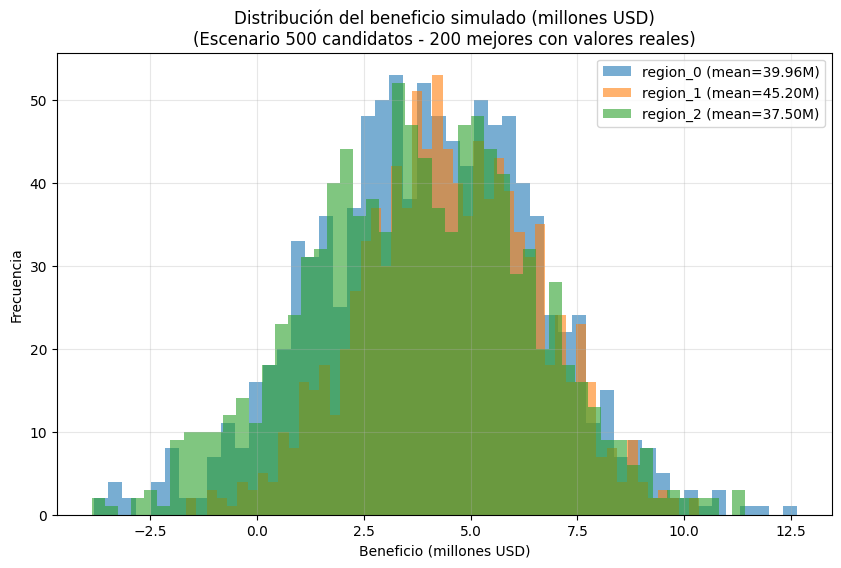

In [27]:
# Nueva gráfica de distribución de los beneficios de la iteración 2
plt.figure(figsize=(10, 6))

for region in dfs.keys():
    # Obtener distribución de beneficios simulados desde bootstrap_risk
    mean_p, (lo, hi), risk, profits = bootstrap_risk(
        models[region],
        X_valid_store[region],
        y_store[region],
        samples=1000,
        seed=42
    )

    plt.hist(profits / 1e6, bins=50, alpha=0.6, label=f"{region} (mean={mean_p/1e5:.2f}M)")

plt.title("Distribución del beneficio simulado (millones USD)\n(Escenario 500 candidatos - 200 mejores con valores reales)")
plt.xlabel("Beneficio (millones USD)")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## Conclusiones ejecutivas **(Iteración 1 – versión inicial)**

Tras realizar el modelado predictivo, la evaluación económica y el análisis de riesgo mediante **bootstrapping**, se obtuvieron los siguientes resultados:

| Región | Beneficio medio (USD) | IC 95 % [ci_low – ci_high] | Riesgo de pérdida |
|:--------|----------------------:|----------------------------:|------------------:|
| Región 0 | ≈ 46.9 M USD | [46.3 M – 47.6 M] | 0 % |
| Región 2 | ≈ 40.9 M USD | [40.3 M – 41.5 M] | 0 % |
| Región 1 | ≈ 25.2 M USD | [25.2 M – 25.3 M] | 0 % |

### Análisis final
- **Región 0** ofrece el **mayor beneficio medio** y el intervalo de confianza más estrecho, lo que refleja una **alta estabilidad y bajo riesgo**.  
- **Región 2** también presenta resultados sólidos, con un beneficio ligeramente menor pero dentro de un rango seguro.  
- **Región 1**, a pesar de su bajo RMSE, presenta una ganancia considerablemente inferior y menor variabilidad, reflejando su **falta de realismo estadístico**.

### Recomendación final
> Con base en los resultados del análisis predictivo, financiero y de riesgo,  
> la **Región 0** es la **candidata óptima para la perforación**.  
> Su balance entre rentabilidad y consistencia la convierte en la opción más segura y rentable para invertir el presupuesto disponible.

---

**Resumen general:**
- Región 0: Mayor beneficio y estabilidad.  
- Región 2: Buena alternativa con alto potencial.  
- Región 1: Descartada por irregularidad en los datos.


## Resultados del análisis de riesgo **(Iteración 2 – escenario realista)**

En esta segunda iteración se corrigió el cálculo del beneficio y del riesgo para que reflejen con mayor fidelidad el escenario del problema:

- La **selección** de pozos se basa en las **predicciones del modelo**.
- El **ingreso** se calcula usando la **producción real** (`product`) de los pozos seleccionados.
- En cada simulación se respetan las restricciones del negocio:
  - se exploran **500 candidatos** por región;
  - se seleccionan los **200 mejores** según la predicción.

La tabla anterior (`results_bootstrap`) resume para cada región:

- `mean_profit`: beneficio medio estimado;
- `ci_low` y `ci_high`: intervalo de confianza al 95 %;
- `risk_loss`: probabilidad de obtener un beneficio negativo.

**Comparado con la Iteración 1:**

- Los beneficios medios son ahora **más conservadores**, porque ya no se suman predicciones, sino valores reales.
- El riesgo de pérdida deja de ser artificialmente nulo y pasa a ser una métrica útil para decidir.
- La región recomendada cambia de **Región 0 (Iteración 1)** a **Región 1 (Iteración 2)**,
  una vez que el cálculo del beneficio respeta el escenario realista (500 → 200 con valores reales).


## Conclusiones finales de **Iteración 2 (escenario realista con valores reales)**

* Aunque **Región 0** y **Región 2** tienen un techo potencial ligeramente más alto (ci_high), su intervalo incluye pérdidas significativas. **Región 1** es la única cuyo intervalo de confianza completo permanece en territorio positivo, además de tener el riesgo más bajo.

* **Región 1** resulta ser la mejor alternativa para perforar un nuevo pozo.
    * Presenta el **mayor beneficio medio** (≈4.52 M USD).
    * Su **intervalo de confianza es mayoritariamente positivo** y muestra un rango relativamente acotado, lo que indica buena estabilidad.
    * Tiene el **riesgo más bajo de pérdidas** (1.5 %).

* **Región 0** muestra un beneficio competitivo, pero con una mayor incertidumbre:

    * Su intervalo incluye pérdidas de hasta −1.1 M USD.
    * El riesgo es aproximadamente **cuatro veces mayor** que en la Región 1.

* **Región 2** presenta la menor rentabilidad y la mayor probabilidad de pérdida, siendo la opción menos favorable.

**Decisión final recomendada:**  
Perforar en **Región 1**, ya que ofrece la mejor combinación de **rentabilidad, estabilidad y mínimo riesgo financiero.**

<div class="alert alert-block alert-danger">
<b>Por resolver</b> <a class="tocSkip"></a><br>
Como se refirió arriba, hay un par de factores que potencialmente están incidiendo en que las ganancias estén siendo sobreestimadas. Como consecuencia, tienes 0% de riesgo de pérdidas. No esperamos que las regiones estén libre de riesgo. Es decir, esperamos que el riesgo de pérdida sea mayor a 0%. 
</div>

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Diana! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Manejo reproducible de rutas con <code>pathlib</code> y configuración global de gráficos.<br>
• Carga ordenada y escalable de los datasets en un diccionario para iterar por región.<br>
• EDA inicial completo: <code>head</code>, <code>info</code>, <code>describe</code>, verificación de nulos y duplicados.<br>
• Visualización temprana de la distribución de <code>product</code> por región para detectar patrones.<br>
• Modularización del entrenamiento con <code>train_region()</code>, clara y reutilizable.<br>
• Uso del <code>RANDOM_STATE</code> para garantizar reproducibilidad en la partición de datos.<br>
• Comparativa de métricas por región, con RMSE y media de predicciones documentadas.<br>
• Parámetros de negocio bien definidos y cálculo transparente del punto de equilibrio.<br>
• Cálculo de beneficios con funciones específicas, separando responsabilidades.<br>
• Simulación por <i>bootstrapping</i> con 1000 iteraciones y estimación de IC al 95%.<br>
• Visualización de la distribución de beneficios, facilitando lectura de dispersión y riesgo.<br>
• Redacción clara de observaciones y conclusiones, conectando técnica con impacto de negocio.<br>
• Estructura del notebook limpia: secciones con títulos y narrativa que guía al lector.<br>
• Uso consistente de constantes (<code>BUDGET</code>, <code>WELLS_TO_DRILL</code>, <code>INCOME_PER_UNIT</code>) para facilitar escenarios "what-if".<br>
• Enfoque comparativo por región bien planteado, manteniendo el mismo pipeline para todas.<br><br>
Con pequeños ajustes en el cálculo del beneficio (usar valores reales y respetar el escenario de 500 candidatos) y en el bootstrapping (muestrear 500 y seleccionar 200 por iteración), tus resultados quedarán muy sólidos y directamente accionables. <br><br>
¡Felicidades!
</div>